# Pipelines and Exploratory Data Analysis

This week, we saw that a machine learning model is only a small part of the puzzle. It relies on us to have
 - Well established, well documented pipelines
 - A good understanding of the dataset
 - A well prepared dataset

Today's tutorial will explore the first 3 stages of CRISP-DM: Business Understanding, Data Understanding and Data Preparation. EDA is part of these last two stages. 

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## CRISP-DM: Business Understanding 
We aim to be able to predict who survived the Titanic disaster based on certain characteristics.
 - What is the success criteria?
 - What resources do we have available? 
 - What metrics should we use to determine success? 
 - Produce a project plan



# CRISP-DM: Data Understanding
## EDA: Inspect Data

- Collect initial data: the data we have available to us is the [Titanic](https://www.kaggle.com/c/titanic/data) dataset, which can be loaded using the `seaborn` and `pandas` libraries. 

In [2]:
df = sns.load_dataset('titanic')
df.head()

# What are the variable types? Ordinal, nominal, numeric?

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.shape

(891, 15)

- Describe data: pandas has lots of useful methods to inspect our data...

In [4]:
df.info()

# How many rows and columns?
# Which variables seem to be categorical? 
# Which variables do you expect to have missing values?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

# Means and std of numeric variables - are they sensible? Are the units what you expect? 
# A good way to initially spot outliers

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## EDA: Missing Data

In [7]:
df.isna().sum()

# Why do you think some of the variables have missing values? Are they missing at random? Or is the missingness related to the value of the variable itself?
# Or to the value of another variable?
# Often requires domain knowledge, but we can investigate

# e.g., age might have not been recorded for passengers in third class, or for passengers who did not survive. missing at random
# embarked: very small number, likely because of data entry error - probably missing completely at random
# deck: recorded probably only for passengers in first class, so missingness is related to the value of the variable itself - missing not at random


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [8]:
df.groupby("pclass")["age"].apply(lambda x: x.isna().mean())

# 30% of ages are missing for passengers in third class, suggesting that missingness is indeed related to the class - MAR.

pclass
1    0.138889
2    0.059783
3    0.276986
Name: age, dtype: float64

In [9]:
df["deck_missing"] = df["deck"].isna()

print(df.groupby("pclass")["deck_missing"].mean())

del df["deck_missing"]

# almost all passengers in third class have missing deck information, so it seems like this is missing because of class - MAR.
# however, the deck information might have been recorded only for passengers in first class, so it could also be missing because of the value of the variable itself - MNAR. Usually harder to prove MNAR from the data, rather than context.

pclass
1    0.189815
2    0.913043
3    0.975560
Name: deck_missing, dtype: float64


In [10]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


How should we deal with these missing values? 
 - Embarked: Only 2 values, perhaps we impute. Could do something sophisticated like regression between age, class and fare, but will just fill in with the mode for the sake of this tutorial


In [11]:
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df['embark_town'].isna().sum(), df['embarked'].isna().sum()

(0, 0)

 - Age: Missingness is related to class, so let's do a group-wise median imputation. Again, we could go for a regression or kNN imputation: try `sklearn.impute.IterativeImputer` or `sklearn.impute.KNNImputer` yourselves.

In [12]:
df['age'] = df.groupby("pclass")["age"].transform(lambda x: x.fillna(x.median()))
df['age'].isna().sum()

0

 - Deck: Missingness is not at random, and we are missing 688 out of 891 records, ~77%. Would recommend *dropping* this variable.

Another option would be to keep the variable and change the NA to unknown. Given that it is MNAR, this information might be useful to an ML model. 

In [13]:
df = df.drop(columns=["deck"])

df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## EDA: Explore data!
### Univariate analysis

In [14]:
for col in df.columns:
    if df[col].dtype != float:
        print(df[col].value_counts())

survived
0    549
1    342
Name: count, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64
sex
male      577
female    314
Name: count, dtype: int64
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
embarked
S    646
C    168
Q     77
Name: count, dtype: int64
class
Third     491
First     216
Second    184
Name: count, dtype: int64
who
man      537
woman    271
child     83
Name: count, dtype: int64
adult_male
True     537
False    354
Name: count, dtype: int64
embark_town
Southampton    646
Cherbourg      168
Queenstown      77
Name: count, dtype: int64
alive
no     549
yes    342
Name: count, dtype: int64
alone
True     537
False    354
Name: count, dtype: int64


C:\Users\mcken\AppData\Local\Temp\ipykernel_5712\4178168370.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.hist(ax=ax);


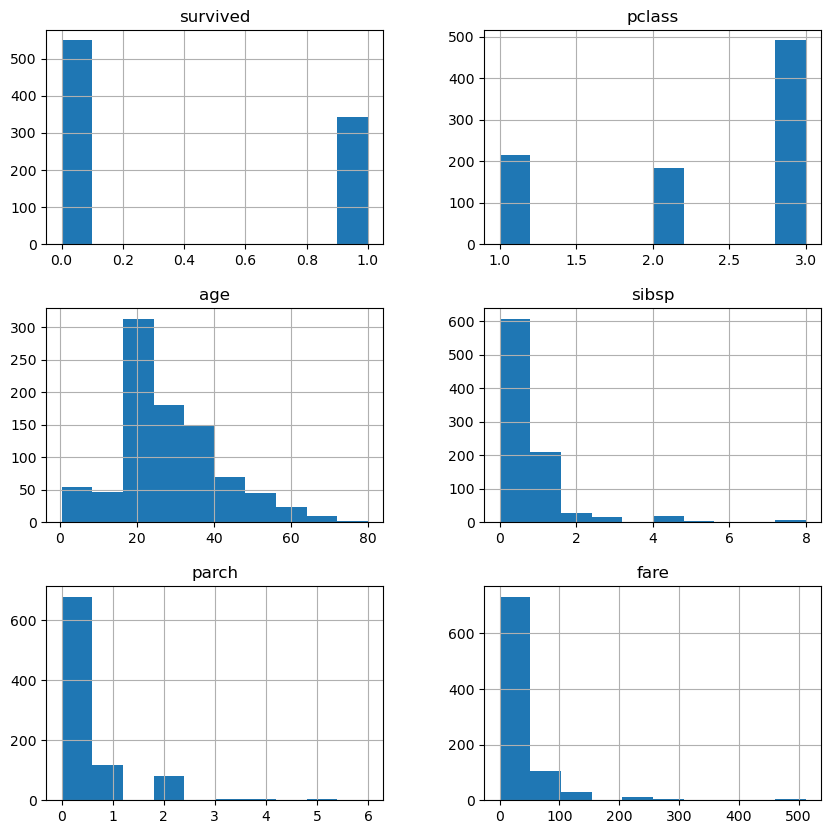

In [15]:
fig, ax = plt.subplots(figsize=(10,10))
df.hist(ax=ax);

pclass
1    216
2    184
3    491
Name: count, dtype: int64


<Axes: xlabel='pclass'>

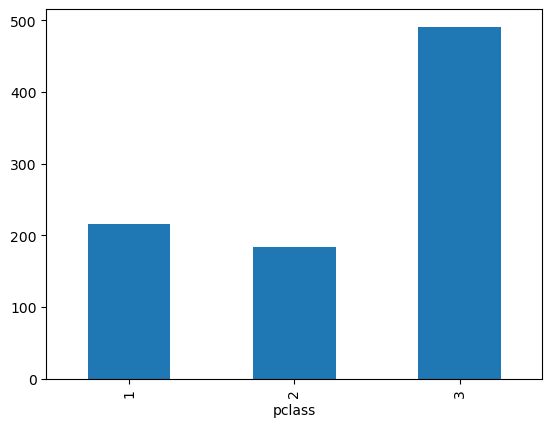

In [16]:
# Frequency tables
print(df['pclass'].value_counts().sort_index())
# Bar plot
df['pclass'].value_counts().sort_index().plot(kind='bar')

# Most common class? 
# How many passengers were in each class?

embarked
C    168
Q     77
S    646
Name: count, dtype: int64


<Axes: xlabel='embarked'>

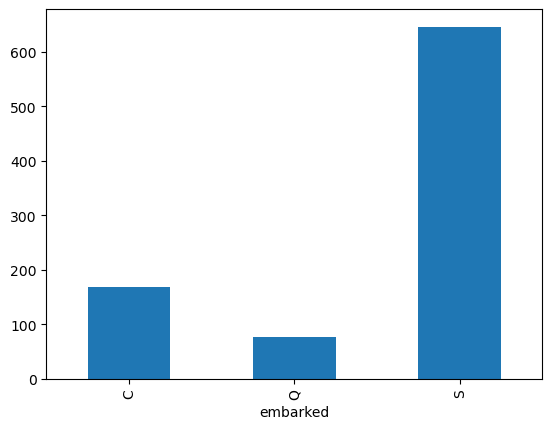

In [17]:
# Frequency tables
print(df['embarked'].value_counts().sort_index())
# Bar plot
df['embarked'].value_counts().sort_index().plot(kind='bar')

# Most common embarkation point?

<Axes: >

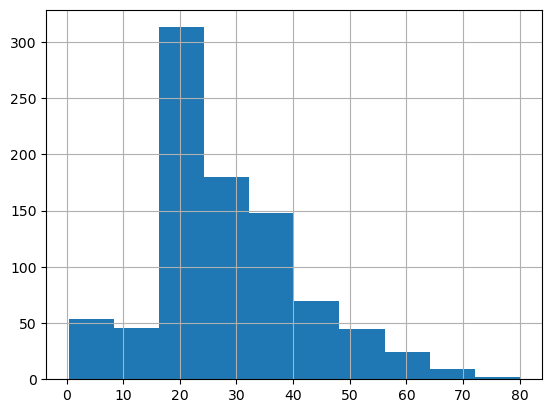

In [18]:
df["age"].hist()

# What is the distribution of ages? Are there any outliers? Does it look like a normal distribution?

In [19]:
df['age'].skew(), df['age'].kurtosis()

# Skewness is positive, so the distribution is right-skewed - right tail is longer than left tail.
# Kurtosis is positive, so the distribution has more extreme values than a normal distribution.

(0.548255729646475, 0.7827902752444)

<Axes: >

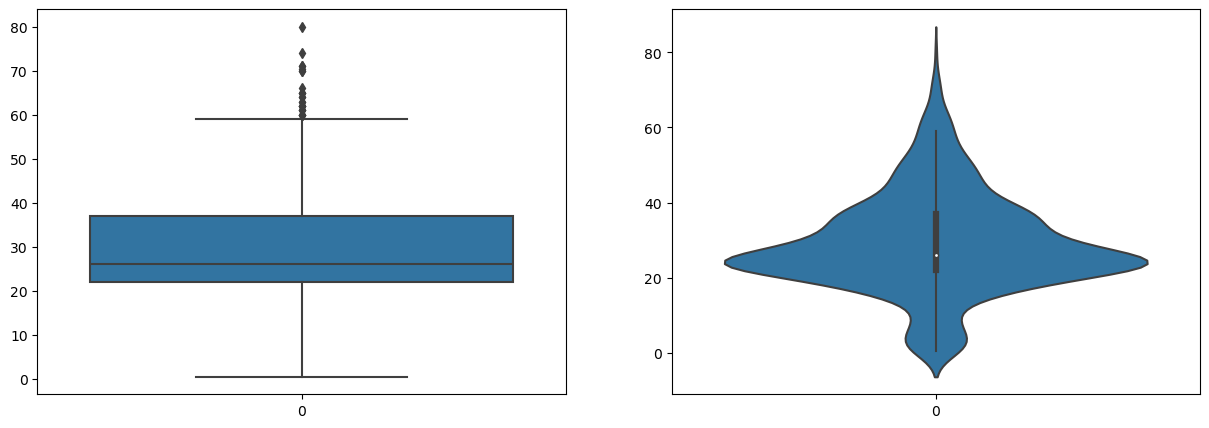

In [20]:

fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(df['age'], ax=ax[0])
sns.violinplot(df['age'], ax=ax[1]) 

# Shows some outliers at the upper end of the distribution, which is consistent with the positive skewness and kurtosis and the histogram.

<Axes: >

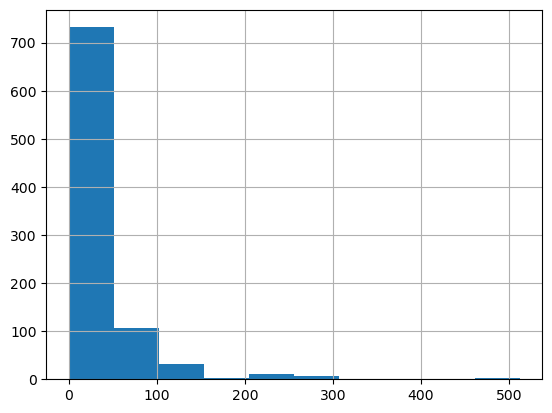

In [21]:
df["fare"].hist()

# What is the distribution of ages? Are there any outliers? Does it look like a normal distribution?

In [22]:
df['fare'].skew(), df['fare'].kurtosis()

# Skewness is very positive, so the distribution is very right-skewed - right tail is longer than left tail.
# Kurtosis is very positive, so the distribution has many more extreme values than a normal distribution.

(4.787316519674893, 33.39814088089868)

<Axes: >

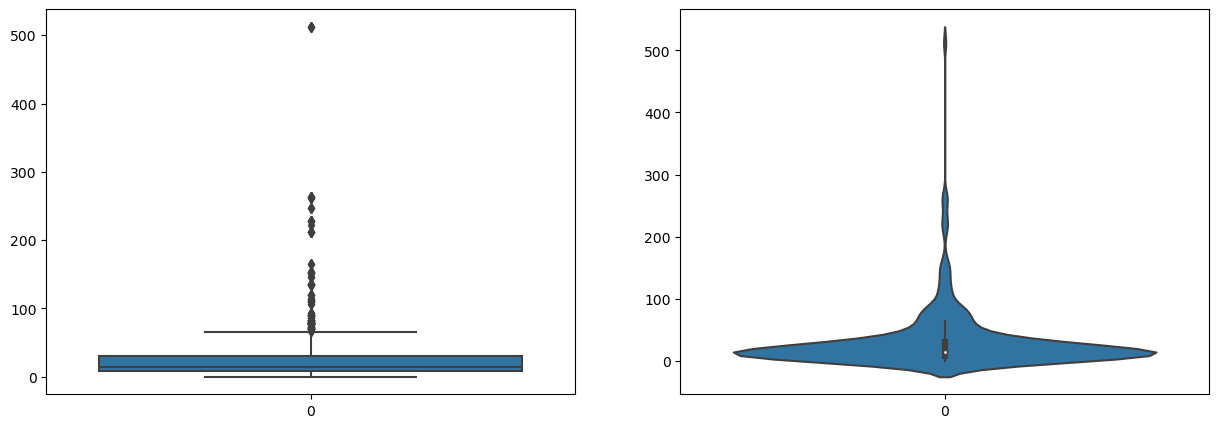

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(df['fare'], ax=ax[0])
sns.violinplot(df['fare'], ax=ax[1])

# Shows many outliers at the upper end of the distribution, which is consistent with the positive skewness and kurtosis and the histogram.

<Axes: xlabel='parch'>

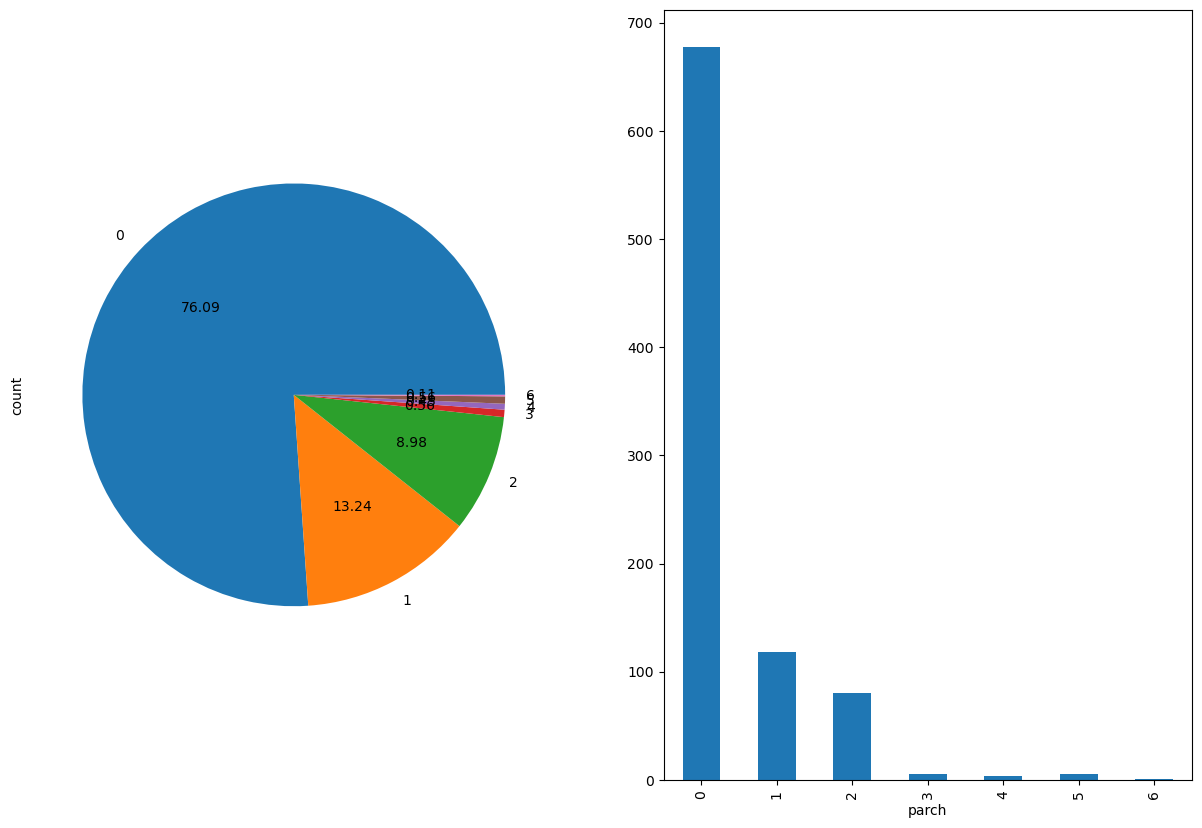

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(15,10))
df_who_counts = df["parch"].value_counts().sort_index()
df_who_counts.plot.pie(autopct='%.2f', ax=ax[0])
df_who_counts.plot.bar(ax=ax[1])

### Multivariate Analysis

In [25]:
# Qualitative vs qualitative
pd.crosstab(df["pclass"], df["survived"])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


In [26]:
pd.crosstab([df["pclass"], df["sex"]], df["survived"])

survived         0   1
pclass sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

<Axes: xlabel='pclass', ylabel='age'>

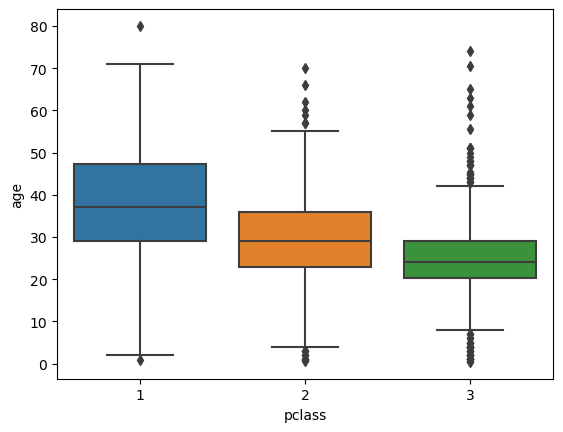

In [27]:
# Qualitative vs quantitative 
sns.boxplot(x="pclass", y="age", data=df)

<Axes: xlabel='pclass', ylabel='fare'>

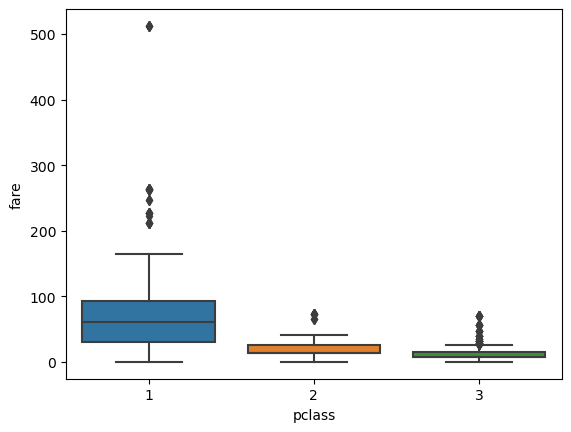

In [28]:
fig, ax = plt.subplots()
sns.boxplot(x="pclass", y="fare", data=df, ax=ax)
# ax.set_ylim(0, 200)

<Axes: xlabel='age', ylabel='fare'>

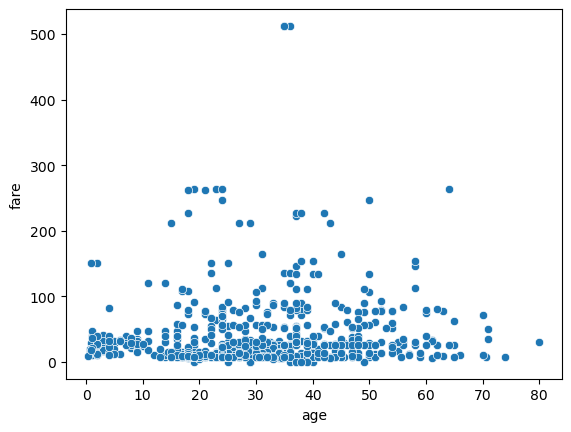

In [29]:
# Quantitative vs quantitative
sns.scatterplot(x="age", y="fare", data=df)

<Axes: >

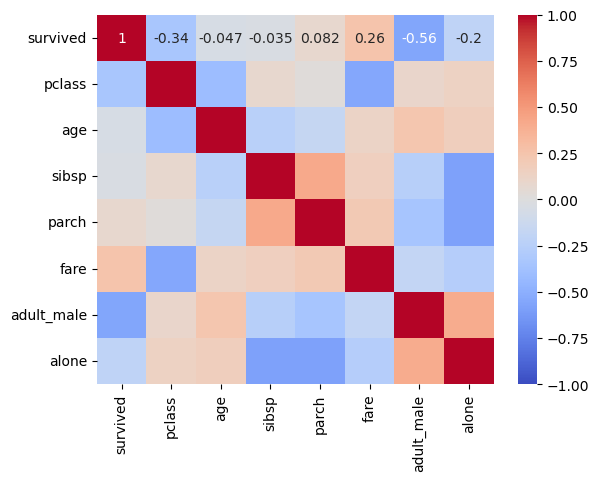

In [30]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)

c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

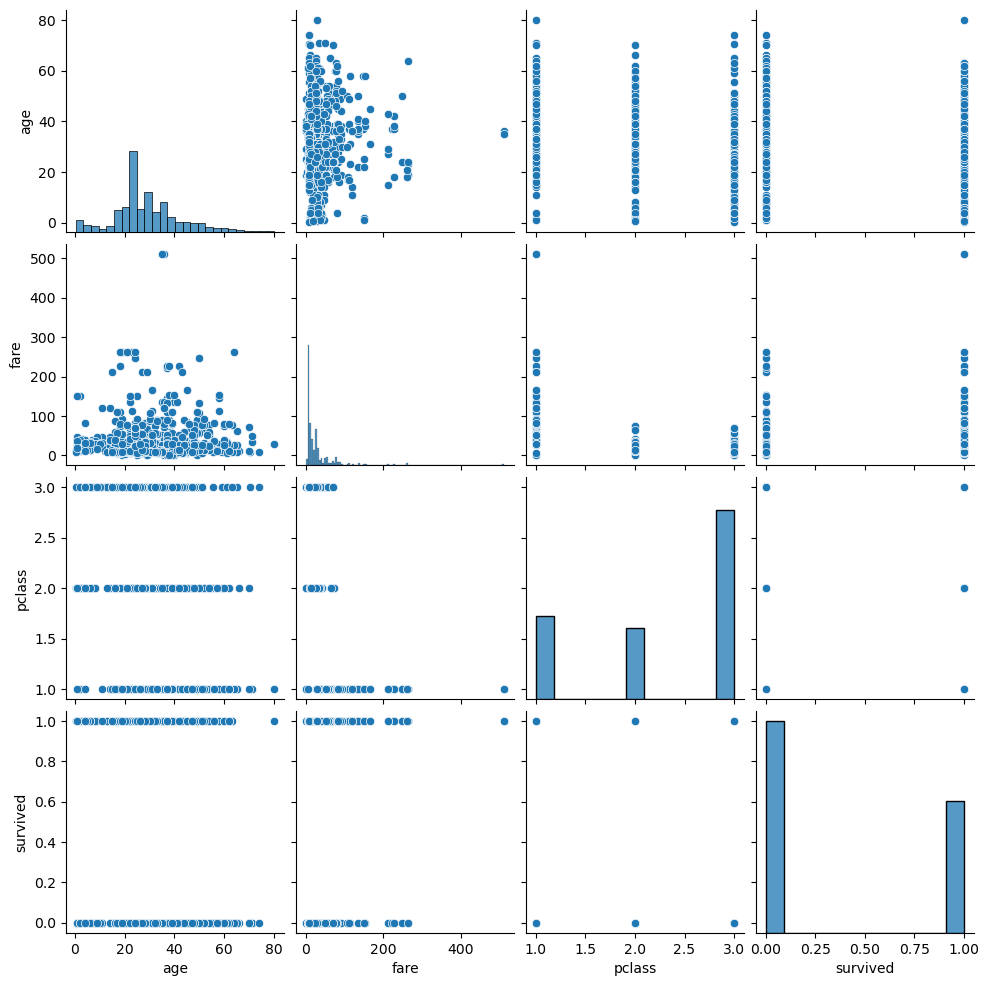

In [31]:
sns.pairplot(df[["age","fare","pclass","survived"]])

c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\mcken\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


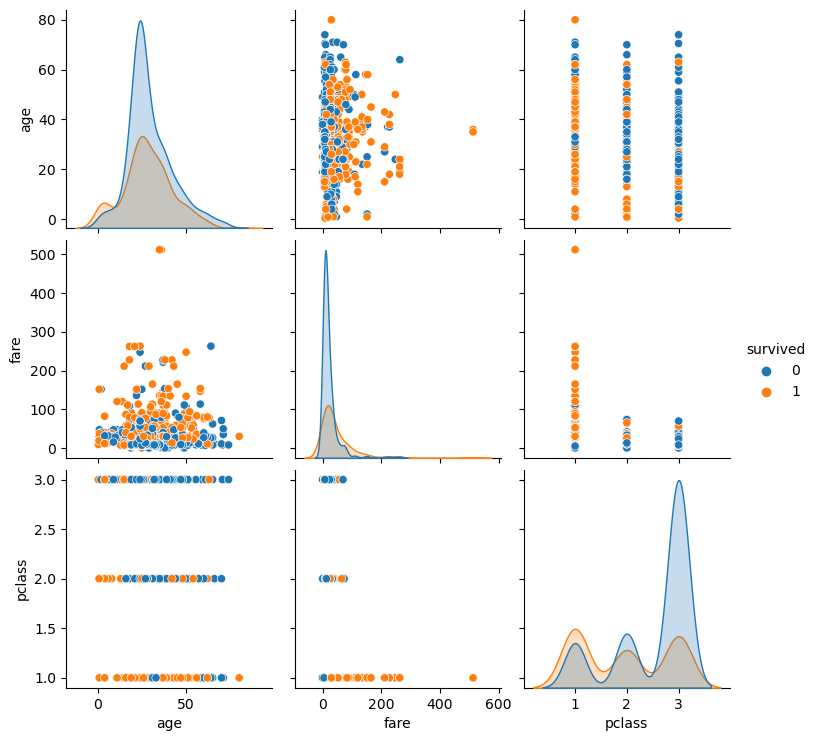

In [32]:
sns.pairplot(df[["age","fare","pclass","survived"]], hue="survived")

In [33]:
# sns.pairplot(df, hue = "survived")

<Axes: xlabel='who', ylabel='survived'>

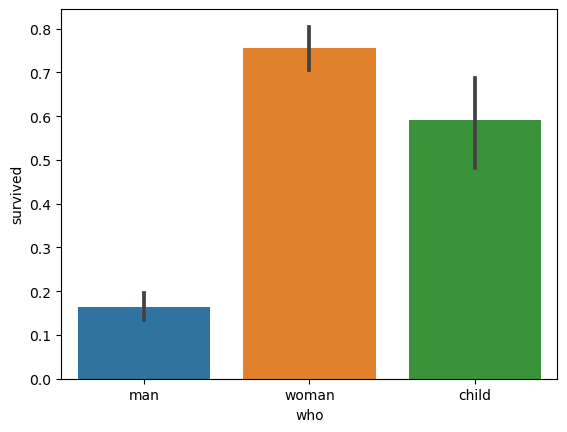

In [34]:
sns.barplot(x="who", y="survived", data=df)

## EDA: Outliers
Looking back through these plots, are their any obvious outliers?
Perhaps fare at $500
Some large families in parch/sibsp
Age?

## EDA: Transformations

Are there any variables that we should not keep? Let's remove the target

In [35]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [36]:
df_target = df["survived"]
df_features = df.drop(columns=["survived"])

Is there any information we would not have available for new data points? Anything that is a proxy for the target?

In [37]:
pd.crosstab(df["alive"], df["survived"])

survived,0,1
alive,,
no,549,0
yes,0,342


In [38]:
df_features.drop(columns=["alive"], inplace=True)

Is p-class equivalent to class?

In [39]:
pd.crosstab(df["class"], df["pclass"])

pclass,1,2,3
class,,,
First,216,0,0
Second,0,184,0
Third,0,0,491


In [40]:
df_features.drop(columns=["class"], inplace=True)

In [41]:
pd.crosstab(df["embark_town"], df["embarked"])

embarked,C,Q,S
embark_town,,,
Cherbourg,168,0,0
Queenstown,0,77,0
Southampton,0,0,646


In [42]:
df_features.drop(columns=["embark_town"], inplace=True)

In [43]:
pd.crosstab(df["sex"], df["who"])
pd.crosstab([df["sex"], df["who"]], df["adult_male"])

adult_male    False  True 
sex    who                
female child     43      0
       woman    271      0
male   child     40      0
       man        0    537

In [44]:
df_features.head()

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,female,35.0,1,0,53.1000,S,woman,False,False
4,3,male,35.0,0,0,8.0500,S,man,True,True


### Transform qualitative variables to quantitative

In [45]:
# Binary variables can be encoded as 0 and 1, which is more efficient for machine learning algorithms.
df_features['sex'] = df_features['sex'].map({"male": 0, "female": 1})
df_features['adult_male'] = df_features['adult_male'].map({True: 1, False: 0})
df_features['alone'] = df_features['alone'].map({True: 1, False: 0})
df_features.head()

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,3,0,22.0,1,0,7.2500,S,man,1,0
1,1,1,38.0,1,0,71.2833,C,woman,0,0
2,3,1,26.0,0,0,7.9250,S,woman,0,1
3,1,1,35.0,1,0,53.1000,S,woman,0,0
4,3,0,35.0,0,0,8.0500,S,man,1,1


In [46]:
df_features = pd.get_dummies(df_features, columns=["embarked"], dtype=int) # drop first category to avoid multicollinearity
df_features.head()

,pclass,sex,age,sibsp,parch,fare,who,adult_male,alone,embarked_C,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,man,1,0,0,0,1
1,1,1,38.0,1,0,71.2833,woman,0,0,1,0,0
2,3,1,26.0,0,0,7.9250,woman,0,1,0,0,1
3,1,1,35.0,1,0,53.1000,woman,0,0,0,0,1
4,3,0,35.0,0,0,8.0500,man,1,1,0,0,1


In [47]:
df_features = pd.get_dummies(df_features, columns=["who"], dtype=int)
df_features.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alone,embarked_C,embarked_Q,embarked_S,who_child,who_man,who_woman
0,3,0,22.0,1,0,7.2500,1,0,0,0,1,0,1,0
1,1,1,38.0,1,0,71.2833,0,0,1,0,0,0,0,1
2,3,1,26.0,0,0,7.9250,0,1,0,0,1,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,0,0,1,0,0,1
4,3,0,35.0,0,0,8.0500,1,1,0,0,1,0,1,0


All the data is numeric, there are no missing values, and we've removed any repeated variables or variables that directly predict our target. Seems like we're ready to use the data in a ML model! 